In [2]:
!pip install scikeras
!pip install --upgrade scikeras scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from scikeras.wrappers import KerasClassifier

np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print("Train images shape:", x_train_raw.shape)
print("Train labels shape:", y_train_raw.shape)
print("Test images shape :", x_test_raw.shape)
print("Test labels shape :", y_test_raw.shape)
print("Pixel value range  :", x_train_raw.min(), "-", x_train_raw.max())
print("Number of classes  :", len(np.unique(y_train_raw)))


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape : (10000, 28, 28)
Test labels shape : (10000,)
Pixel value range  : 0 - 255
Number of classes  : 10


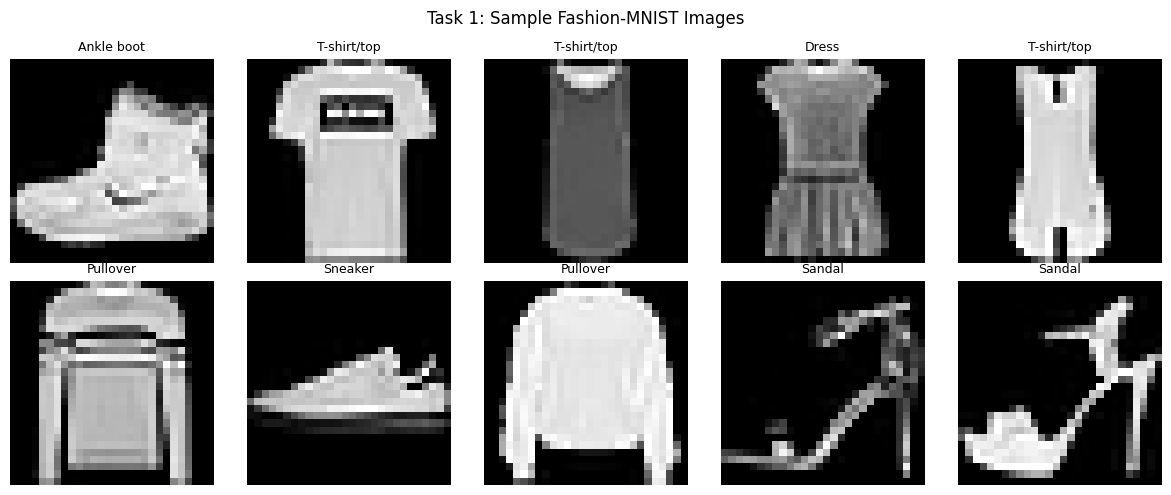

In [6]:
# Display 10 sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_raw[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train_raw[i]], fontsize=9)
    ax.axis('off')
plt.suptitle("Task 1: Sample Fashion-MNIST Images")
plt.tight_layout()
plt.savefig('plot1_sample_images.png')
plt.show()


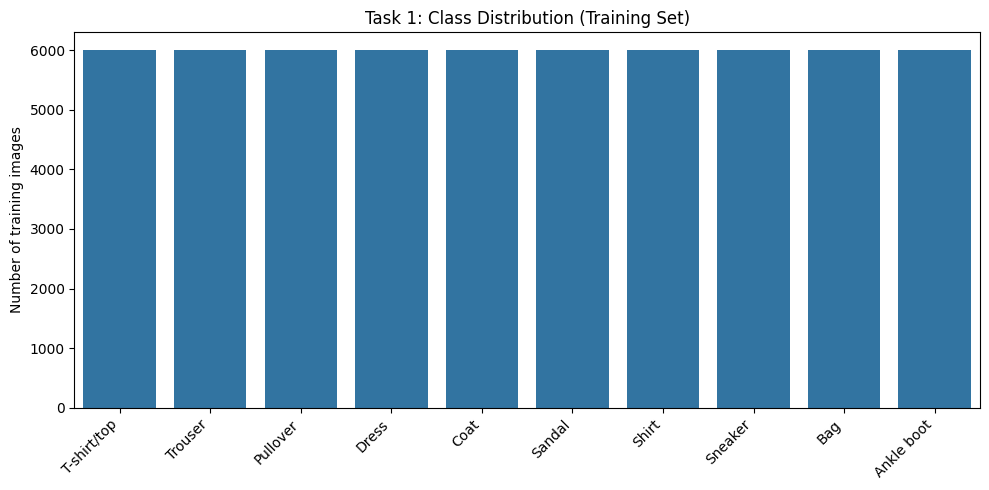

Class counts: {'T-shirt/top': np.int64(6000), 'Trouser': np.int64(6000), 'Pullover': np.int64(6000), 'Dress': np.int64(6000), 'Coat': np.int64(6000), 'Sandal': np.int64(6000), 'Shirt': np.int64(6000), 'Sneaker': np.int64(6000), 'Bag': np.int64(6000), 'Ankle boot': np.int64(6000)}


In [ ]:
# Class distribution
plt.figure(figsize=(10, 5))
counts = np.bincount(y_train_raw)
sns.barplot(x=CLASS_NAMES, y=counts)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of training images")
plt.title("Task 1: Class Distribution (Training Set)")
plt.tight_layout()
plt.savefig('plot2_class_distribution.eps', dpi=600)
plt.show()

print("Class counts:", dict(zip(CLASS_NAMES, counts)))


In [ ]:
print("BEFORE preprocessing")
print("x_train:", x_train_raw.shape, x_train_raw.dtype)
print("y_train:", y_train_raw.shape, y_train_raw.dtype)

# Flatten
x_train = x_train_raw.reshape(x_train_raw.shape[0], 784).astype('float32')
x_test = x_test_raw.reshape(x_test_raw.shape[0], 784).astype('float32')

# Normalize to [0,1]
x_train /= 255.0
x_test /= 255.0

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("\nAFTER preprocessing")
print("x_train:", x_train.shape, x_train.dtype, "range:", x_train.min(), "-", x_train.max())
print("y_train:", y_train.shape, y_train.dtype)
print("Example one-hot label:", y_train[0], "-> class", np.argmax(y_train[0]))


BEFORE preprocessing
x_train: (60000, 28, 28) uint8
y_train: (60000,) uint8

AFTER preprocessing
x_train: (60000, 784) float32 range: 0.0 - 1.0
y_train: (60000, 10) float64
Example one-hot label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.] -> class 9


In [ ]:
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

start = time.time()
history = baseline_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)
baseline_train_time = time.time() - start
print(f"\nBaseline training time: {baseline_train_time:.2f} seconds")


Epoch 1/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8201 - loss: 0.5055 - val_accuracy: 0.8510 - val_loss: 0.4035
Epoch 2/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8643 - loss: 0.3727 - val_accuracy: 0.8572 - val_loss: 0.3934
Epoch 3/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8771 - loss: 0.3342 - val_accuracy: 0.8620 - val_loss: 0.3699
Epoch 4/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8844 - loss: 0.3111 - val_accuracy: 0.8655 - val_loss: 0.3668
Epoch 5/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8919 - loss: 0.2908 - val_accuracy: 0.8615 - val_loss: 0.3734
Epoch 6/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8972 - loss: 0.2750 - val_accuracy: 0.8642 - val_loss: 0.3807
Epoch 7/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9013 - loss: 0.2623 - val_accuracy: 0.8638 - val_loss: 0.3907
Epoch 8/50
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9047 - loss: 0.2531 - 

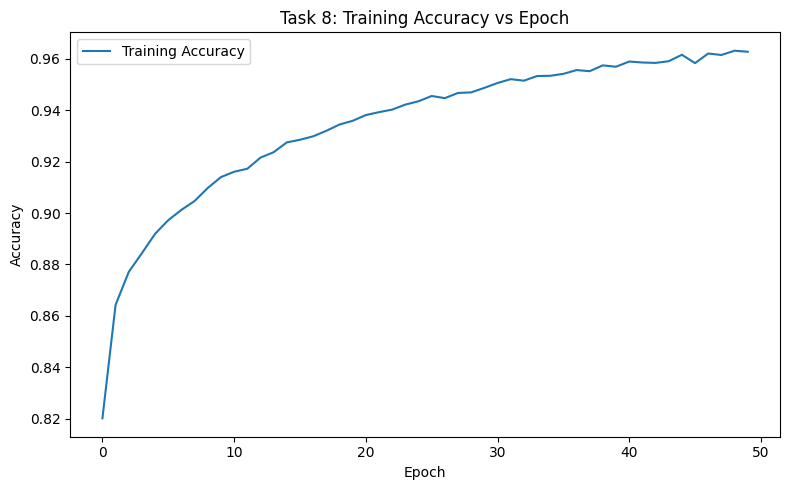

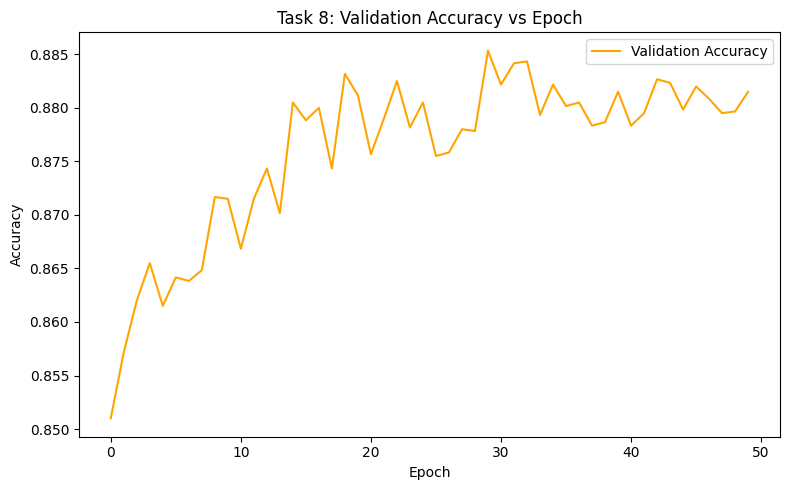

In [ ]:
# Training/Validation Accuracy vs Epoch
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Task 8: Training Accuracy vs Epoch')
plt.legend(); plt.tight_layout()
plt.savefig('plot3_train_accuracy.eps', dpi=600); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Task 8: Validation Accuracy vs Epoch')
plt.legend(); plt.tight_layout()
plt.savefig('plot4_val_accuracy.eps', dpi=600); plt.show()


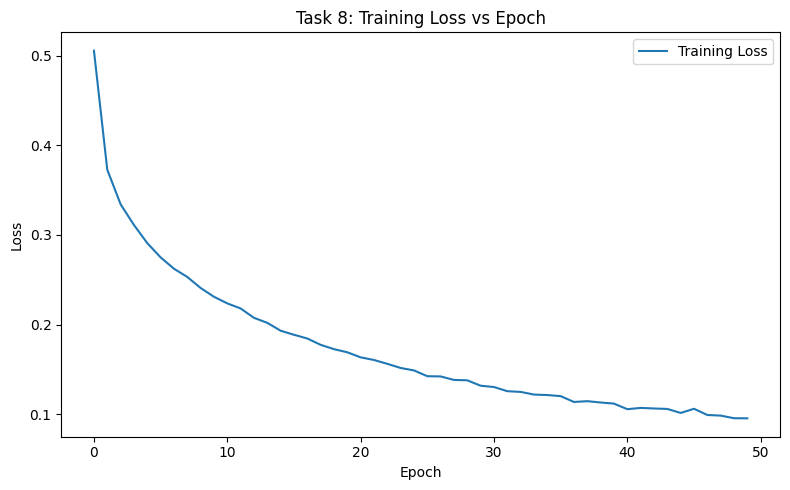

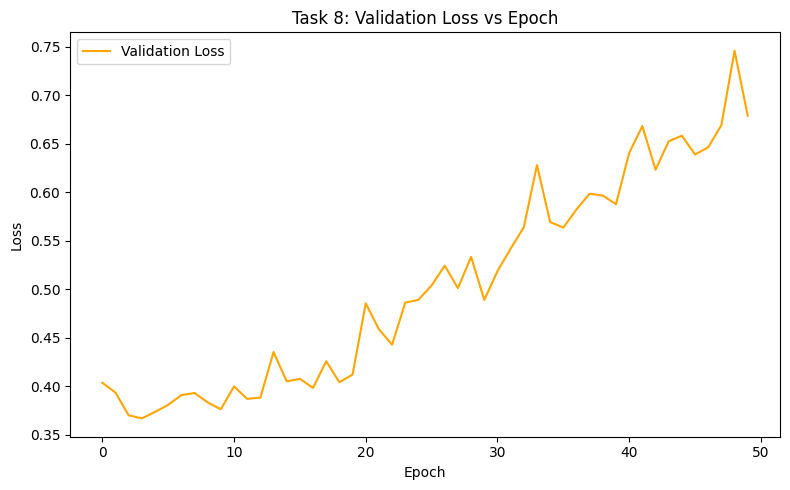

In [ ]:
# Training/Validation Loss vs Epoch
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Task 8: Training Loss vs Epoch')
plt.legend(); plt.tight_layout()
plt.savefig('plot5_train_loss.eps', dpi=600); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Task 8: Validation Loss vs Epoch')
plt.legend(); plt.tight_layout()
plt.savefig('plot6_val_loss.eps', dpi=600); plt.show()


In [ ]:
y_pred_probs = baseline_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

baseline_acc = accuracy_score(y_true, y_pred)
baseline_prec = precision_score(y_true, y_pred, average='weighted')
baseline_rec = recall_score(y_true, y_pred, average='weighted')
baseline_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Baseline Test Accuracy : {baseline_acc:.4f}")
print(f"Baseline Precision     : {baseline_prec:.4f}")
print(f"Baseline Recall        : {baseline_rec:.4f}")
print(f"Baseline F1-score      : {baseline_f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Baseline Test Accuracy : 0.8806
Baseline Precision     : 0.8803
Baseline Recall        : 0.8806
Baseline F1-score      : 0.8801

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.81      0.82      0.82      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.80      0.77      0.78      1000
       Dress       0.87      0.89      0.88      1000
        Coat       0.77      0.83      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.71      0.67      0.69      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.96      0.97      0.96      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



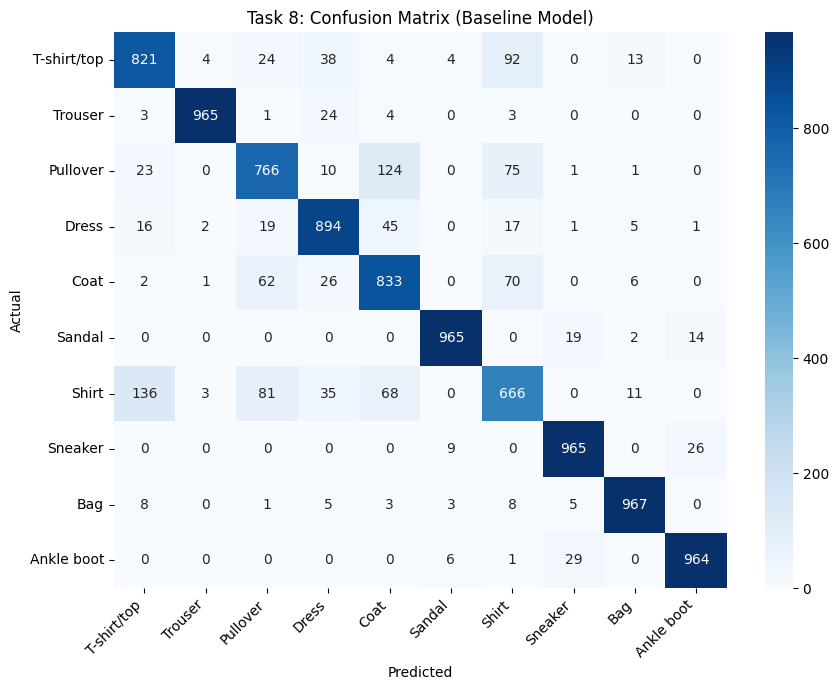

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Task 8: Confusion Matrix (Baseline Model)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot7_confusion_matrix.eps', dpi=600); plt.show()


In [ ]:
def build_tunable_model(hidden_layers=2, hidden_neurons=128, learning_rate=0.001,
                         optimizer_name='adam', activation='relu', dropout_rate=0.0):
    model = models.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    if optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# Full search space as specified in the manual
param_distributions = {
    'model__hidden_layers': [1, 2, 3],
    'model__hidden_neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'model__optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
}

N_ITER = 20    # increase if you have time/GPU (manual's full grid = 11,664 combos)
CV_FOLDS = 5      # manual specifies 5; reduce to 3 if this is too slow for you

clf = KerasClassifier(model=build_tunable_model, verbose=0)

# Subsample for search speed only (final model is retrained on full data below)
rng = np.random.default_rng(42)
subsample_idx = rng.choice(len(x_train), size=int(0.10 * len(x_train)), replace=False)
x_search, y_search = x_train[subsample_idx], y_train_raw[subsample_idx]

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42),
    scoring='accuracy',
    random_state=42,
    n_jobs=1,
    verbose=2
)

start = time.time()
search.fit(x_search, y_search)
search_time = time.time() - start
print(f"\nSearch completed in {search_time/60:.1f} minutes")
print("Best CV accuracy:", search.best_score_)
print("Best hyperparameters:", search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   7.8s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   6.7s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   7.3s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   6.2s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_

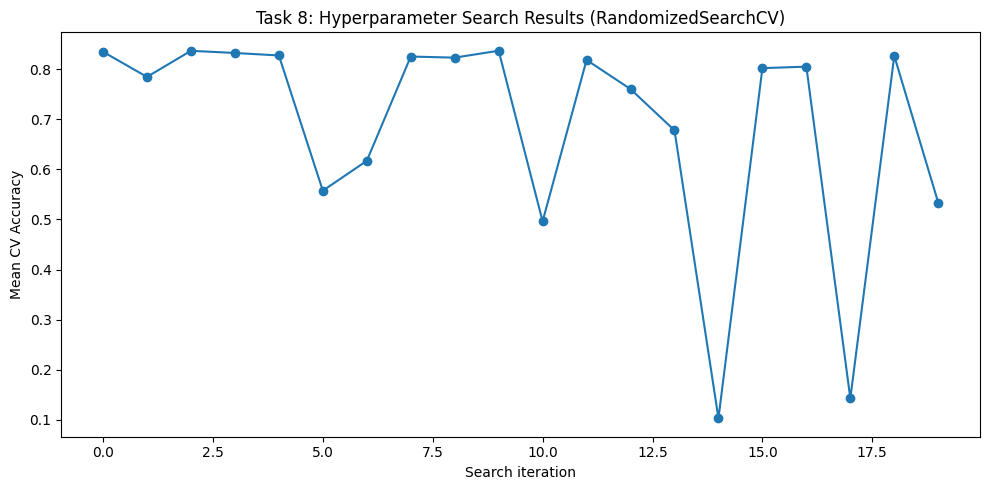

In [ ]:
cv_results = search.cv_results_
plt.figure(figsize=(10,5))
plt.plot(cv_results['mean_test_score'], marker='o')
plt.xlabel('Search iteration')
plt.ylabel('Mean CV Accuracy')
plt.title('Task 8: Hyperparameter Search Results (RandomizedSearchCV)')
plt.tight_layout()
plt.savefig('plot8_hp_search_results.eps', dpi=600); plt.show()


In [ ]:
best_params = search.best_params_

optimized_model = build_tunable_model(
    hidden_layers=best_params['model__hidden_layers'],
    hidden_neurons=best_params['model__hidden_neurons'],
    learning_rate=best_params['model__learning_rate'],
    optimizer_name=best_params['model__optimizer_name'],
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate'],
)
optimized_model.summary()

start = time.time()
opt_history = optimized_model.fit(
    x_train, y_train_raw,
    validation_split=0.1,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=1
)
optimized_train_time = time.time() - start
print(f"\nOptimized model training time: {optimized_train_time:.2f} seconds")


Model: "sequential_102"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_291 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_292 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_293 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8034 - loss: 0.5504 - val_accuracy: 0.8495 - val_loss: 0.4020
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8601 - loss: 0.3849 - val_accuracy: 0.8670 - val_loss: 0.3646
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8738 - loss: 0.3459 - val_accuracy: 0.8687 - val_loss: 0.3489
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8822 - loss: 0.3194 - val_accuracy: 0.8723 - val_loss: 0.3389
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8891 - loss: 0.2982 - val_accuracy: 0.8767 - val_loss: 0.3332
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8951 - loss: 0.2800 - val_accuracy: 0.8780 - val_loss: 0.3319
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9009 - loss: 0.2644 - val_accuracy: 0.8803 - val_loss: 0.3321
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9061 - loss: 0.2498 - 

In [ ]:
y_pred_opt_probs = optimized_model.predict(x_test)
y_pred_opt = np.argmax(y_pred_opt_probs, axis=1)

opt_acc = accuracy_score(y_true, y_pred_opt)
opt_prec = precision_score(y_true, y_pred_opt, average='weighted')
opt_rec = recall_score(y_true, y_pred_opt, average='weighted')
opt_f1 = f1_score(y_true, y_pred_opt, average='weighted')

print(f"Optimized Test Accuracy : {opt_acc:.4f}")
print(f"Optimized Precision     : {opt_prec:.4f}")
print(f"Optimized Recall        : {opt_rec:.4f}")
print(f"Optimized F1-score      : {opt_f1:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Optimized Test Accuracy : 0.8874
Optimized Precision     : 0.8869
Optimized Recall        : 0.8874
Optimized F1-score      : 0.8858


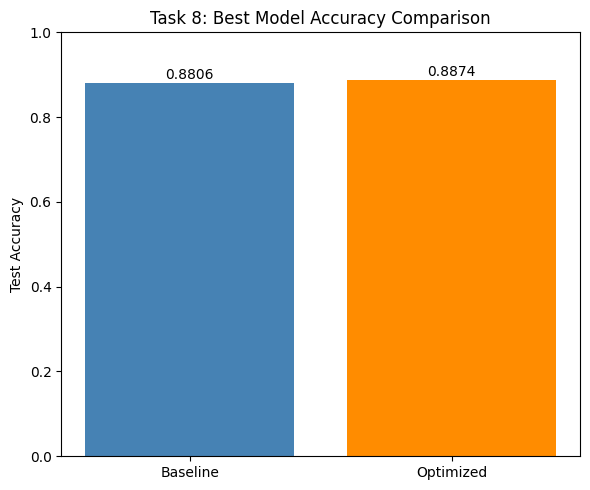

In [ ]:
labels_cmp = ['Baseline', 'Optimized']
accs = [baseline_acc, opt_acc]

plt.figure(figsize=(6,5))
bars = plt.bar(labels_cmp, accs, color=['steelblue', 'darkorange'])
plt.ylabel('Test Accuracy')
plt.title('Task 8: Best Model Accuracy Comparison')
plt.ylim(0, 1)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc:.4f}', ha='center')
plt.tight_layout()
plt.savefig('plot9_accuracy_comparison.eps', dpi=600); plt.show()


In [ ]:
print("Best Hyperparameters")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nCross-validation Accuracy: {search.best_score_:.4f}")
print(f"Testing Accuracy (optimized): {opt_acc:.4f}")


Best Hyperparameters
  model__optimizer_name: adam
  model__learning_rate: 0.001
  model__hidden_neurons: 256
  model__hidden_layers: 2
  model__dropout_rate: 0.0
  model__activation: sigmoid
  epochs: 30
  batch_size: 32

Cross-validation Accuracy: 0.8372
Testing Accuracy (optimized): 0.8874


In [ ]:
print(f"{'Metric':<15}{'Baseline':>12}{'Optimized':>12}")
print(f"{'Accuracy':<15}{baseline_acc:>12.4f}{opt_acc:>12.4f}")
print(f"{'Precision':<15}{baseline_prec:>12.4f}{opt_prec:>12.4f}")
print(f"{'Recall':<15}{baseline_rec:>12.4f}{opt_rec:>12.4f}")
print(f"{'F1-score':<15}{baseline_f1:>12.4f}{opt_f1:>12.4f}")
print(f"{'Train Time(s)':<15}{baseline_train_time:>12.2f}{optimized_train_time:>12.2f}")


Metric             Baseline   Optimized
Accuracy             0.8806      0.8874
Precision            0.8803      0.8869
Recall               0.8806      0.8874
F1-score             0.8801      0.8858
Train Time(s)        263.96      152.32


In [ ]:
import pandas as pd
results_df = pd.DataFrame(search.cv_results_)

# Impact of each hyperparameter on mean CV score
for param in param_distributions.keys():
    col = f'param_{param}'
    if col in results_df.columns:
        print(f"\n--- {param} ---")
        print(results_df.groupby(col)['mean_test_score'].mean().sort_values(ascending=False))



--- model__hidden_layers ---
param_model__hidden_layers
3    0.751222
1    0.722259
2    0.547367
Name: mean_test_score, dtype: float64

--- model__hidden_neurons ---
param_model__hidden_neurons
128    0.755300
64     0.729167
256    0.716262
32     0.553333
Name: mean_test_score, dtype: float64

--- model__learning_rate ---
param_model__learning_rate
0.010    0.798633
0.001    0.779800
0.100    0.390667
Name: mean_test_score, dtype: float64

--- batch_size ---
param_batch_size
128    0.741700
32     0.736861
16     0.668433
64     0.568167
Name: mean_test_score, dtype: float64

--- epochs ---
param_epochs
10    0.757458
30    0.727803
20    0.541767
Name: mean_test_score, dtype: float64

--- model__optimizer_name ---
param_model__optimizer_name
sgd        0.752417
adam       0.694030
rmsprop    0.657905
Name: mean_test_score, dtype: float64

--- model__activation ---
param_model__activation
tanh       0.763379
sigmoid    0.650604
relu       0.142500
Name: mean_test_score, dtype: floa